# Preliminary Data Analysis and Visualization

In [1]:
# Install modules if necessary
# %pip install geopandas

# Import Chunk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Patch

## 1. Load and Prepare Data

In [2]:
# Labeled job ads dataset (without meta data, excluding gold standard ads)
df_labeled = pd.read_parquet("../data/labeled_corpus_final.parquet")

# Job ad dataset (with metadata, including gold standard ads)
df_full = pd.read_parquet("../data/job_ads_cleaned_state.parquet")

# ISCO level 3 code information dataset
df_isco3 = pd.read_csv("../data/isco_level3.csv")


In [3]:
# Sanity check if job-ad titles match based on job_id between the labeled and the full dataset
all(
    df_labeled.loc[df_labeled["job_id"] == id, "title"].iloc[0] 
    == df_full.loc[df_full["job_id"] == id, "title"].iloc[0]
    for id in df_labeled["job_id"].to_list()
)

True

In [4]:
# Join meta data on labeled dataset 
df_labeled = df_labeled.merge(
    df_full[["job_id", "state_code", "state_name", "formatted_experience_level", "listed_date"]],
    on="job_id",
    how="left"
)

In [5]:
# Show cases with invalid labeling
display(df_labeled[df_labeled["isco_valid"]==False])

# Drop them
df_labeled = df_labeled[df_labeled["isco_valid"]]

,job_id,title,text_final,isco,isco_valid,state_code,state_name,formatted_experience_level,listed_date
18742,19212,Assistant Coach of Men's Lacrosse - 302557,Opening Details [ORG] [ORG] is excited to anno...,INVALID,False,MA,Massachusetts,Entry level,2023-08-22 21:33:20
25897,26547,Lighting Supervisor,GENERAL INFORMATIONPosition Title: Lighting Su...,INVALID,False,WA,Washington,None,2023-08-23 00:20:00


In [6]:
# Join occupation titles based on isco code
df_isco3["isco"] = df_isco3["isco_code"].astype(str)
df_isco3.rename(columns={"title": "isco_title"}, inplace=True)

df_labeled = df_labeled.merge(
    df_isco3[["isco", "isco_title"]],
    on="isco",
    how="left"
)

In [7]:
# Add a major group column
df_labeled["major_group"] = df_labeled["isco"].astype(str).str[0]

## 2. Overall ISCO-08 Group Distribution

In [8]:
# Major Group distribution

major_counts = (
    df_labeled["major_group"]
    .value_counts()
    .reindex([str(i) for i in range(10)], fill_value=0)
)

major_share = major_counts / len(df_labeled) * 100

# Most common level-3 occupation within each Major Group
top_isco3 = (
    df_labeled
    .groupby("major_group")["isco"]
    .value_counts()
    .groupby(level=0)
    .head(1)
    .reset_index(name="count")
)

# Add title
top_isco3 = top_isco3.merge(
    df_labeled[["isco", "isco_title"]].drop_duplicates(),
    on="isco",
    how="left"
)

# Share within Major Group
top_isco3["within_major_share"] = (
    top_isco3["count"]
    / top_isco3["major_group"].map(major_counts)
    * 100
)

# Dictionary
top_dict = top_isco3.set_index("major_group").to_dict("index")

In [9]:
# Exact frequencies
df_labeled["isco"].astype(str).str.zfill(3).str[0].value_counts(normalize=True).sort_index()* 100

isco
1    15.674317
2    44.091138
3    19.427040
4     5.776512
5     7.317809
6     0.325013
7     3.866644
8     1.906517
9     1.615011
Name: proportion, dtype: float64

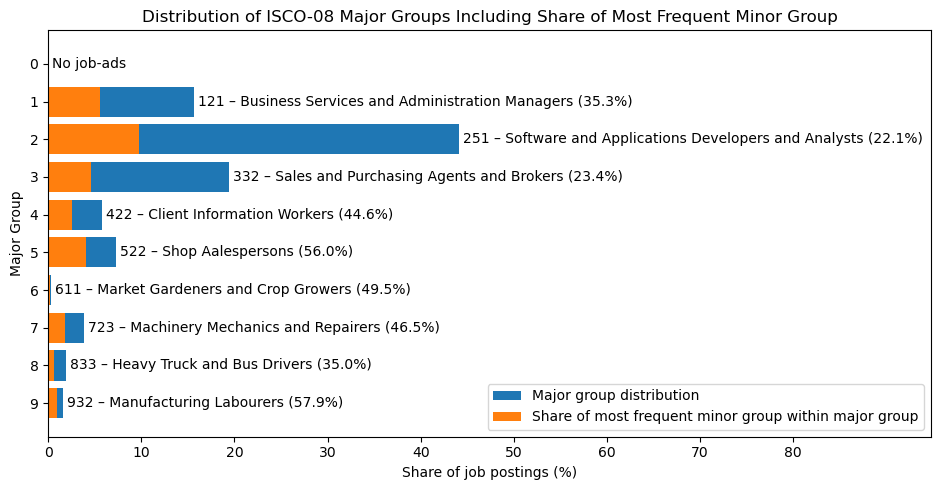

In [10]:
# Visualize
fig, ax = plt.subplots(figsize=(10, 5))

y = range(10)

# Share of most frequent level-3 occupation per major group
top_share = major_share.copy()

for major in major_share.index:
    if major in top_dict:
        top_share.loc[major] = (
            major_share.loc[major]
            * top_dict[major]["within_major_share"] / 100
        )
    else:
        top_share.loc[major] = 0

# Bars
ax.barh(y, major_share.values, color="C0")  # Major Groups
ax.barh(y, top_share.values, color="C1")  # Most frequent Minor Group within Major Group

ax.set_yticks(y)
ax.invert_yaxis()
ax.set_xlabel("Share of job postings (%)")
ax.set_ylabel("Major Group")
ax.set_title("Distribution of ISCO-08 Major Groups Including Share of Most Frequent Minor Group")

# Set labels
max_share = major_share.max()

for i, major in enumerate(major_share.index):

    if major in top_dict:
        info = top_dict[major]

        label = (
            f'{info["isco"]} – {info["isco_title"]} '
            f'({info["within_major_share"]:.1f}%)'
        )
    else:
        label = "No job-ads"

    ax.text(
        major_share.loc[major] + max_share * 0.01,
        i,
        label,
        va="center"
    )

# Legend
legend_elements = [
    Patch(
        facecolor="C0",
        label="Major group distribution"
    ),
    Patch(
        facecolor="C1",
        label="Share of most frequent minor group within major group"
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True
)

ax.set_xlim(0, max_share * 2.15)
ax.set_xticks(range(0, 81, 10))

plt.tight_layout()
plt.show()

## 3. Temporal Analysis

In [11]:
# Prepare Data

# August / November
df_aug = df_labeled[df_labeled["listed_date"].dt.month == 8]
df_nov = df_labeled[df_labeled["listed_date"].dt.month == 11]

# Shares for all major groups 1–9
groups = [str(i) for i in range(1, 10)]

aug_share = (
    df_aug["major_group"]
    .value_counts(normalize=True)
    .reindex(groups, fill_value=0)
    * 100
)

nov_share = (
    df_nov["major_group"]
    .value_counts(normalize=True)
    .reindex(groups, fill_value=0)
    * 100
)

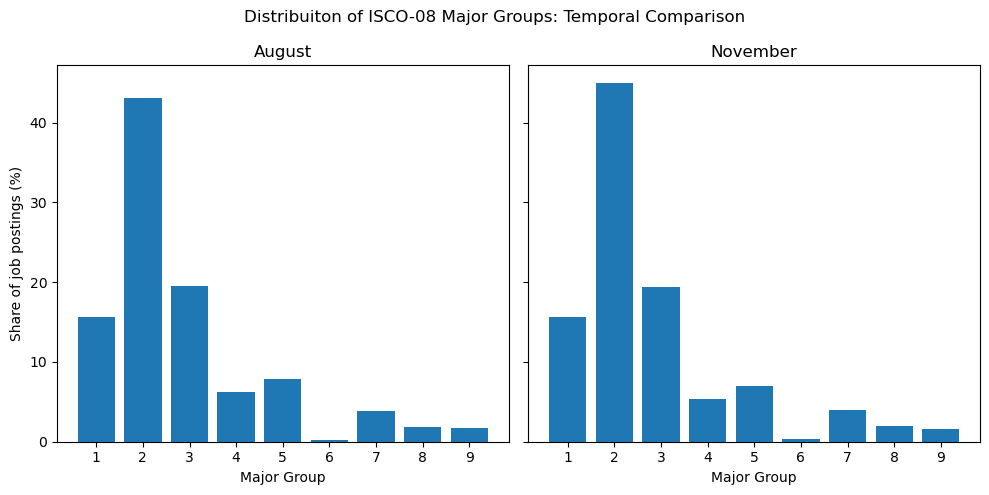

In [12]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
fig.suptitle("Distribuiton of ISCO-08 Major Groups: Temporal Comparison")


axes[0].bar(groups, aug_share.values)
axes[0].set_title("August")
axes[0].set_xlabel("Major Group")
axes[0].set_ylabel("Share of job postings (%)")

axes[1].bar(groups, nov_share.values)
axes[1].set_title("November")
axes[1].set_xlabel("Major Group")
axes[1].set_ylabel("")


plt.tight_layout()
plt.show()

## 4. Geographical Analysis

In [13]:
# Prepare Data

# Only valid major groups
df_map = df_labeled[
    df_labeled["major_group"].isin([str(i) for i in range(1, 10)])
].copy()

# Frquencies per state and major group
state_major = (
    df_map
    .groupby(["state_name", "major_group"])
    .size()
    .reset_index(name="n")
)

# Total number of jobs per state
state_total = (
    state_major
    .groupby("state_name")["n"]
    .sum()
    .reset_index(name="total")
)

state_major = state_major.merge(state_total, on="state_name")

# Share of each major group within each state
state_major["share"] = state_major["n"] / state_major["total"]

# Most frequent (dominant) major group per state
dominant = (
    state_major
    .sort_values(["state_name", "share"], ascending=[True, False])
    .drop_duplicates("state_name")
)

dominant.sort_values(["share"], ascending=False)

,state_name,major_group,n,total,share
283,Non-US,2,13,15,0.866667
381,Unknown,2,1457,2205,0.660771
405,Virginia,2,430,861,0.499419
275,New York,2,952,1925,0.494545
257,New Jersey,2,382,780,0.489744
52,Connecticut,2,158,324,0.487654
101,Idaho,2,60,126,0.476190
250,New Hampshire,2,46,97,0.474227
172,Maryland,2,250,529,0.472590
34,California,2,1811,3868,0.468201


In [14]:
# Get geographical data of states
url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
states = gpd.read_file(url)

states.head()


,id,name,density,geometry
0,01,Alabama,94.650,"POLYGON ((-87.3593 35.00118, -85.60668 34.9847..."
1,02,Alaska,1.264,"MULTIPOLYGON (((-131.60202 55.11798, -131.5691..."
2,04,Arizona,57.050,"POLYGON ((-109.0425 37.00026, -109.04798 31.33..."
3,05,Arkansas,56.430,"POLYGON ((-94.47384 36.50186, -90.15254 36.496..."
4,06,California,241.700,"POLYGON ((-123.23326 42.00619, -122.37885 42.0..."


In [15]:
# Merge major group and geographical data
map_data = states.merge(
    dominant,
    left_on="name",
    right_on="state_name",
    how="left"
)

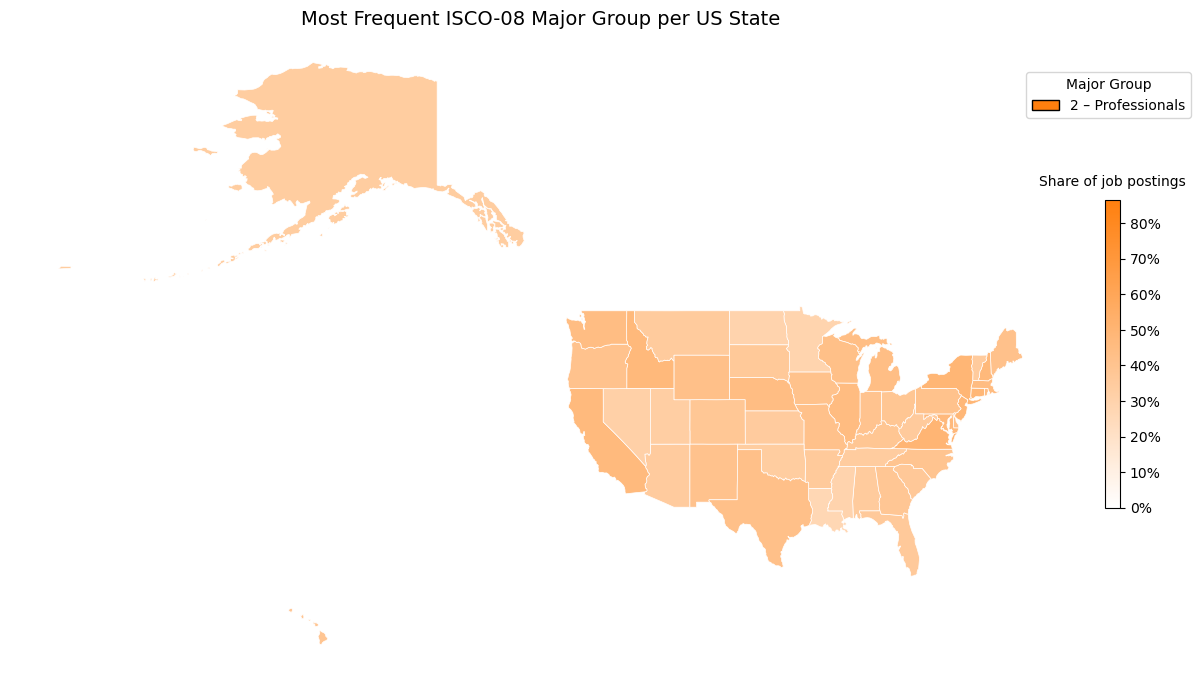

In [16]:
# Visualization

fig, ax = plt.subplots(figsize=(12, 8))

# Colormap for major group 2
base_color = plt.cm.tab10(1)

cmap = mcolors.LinearSegmentedColormap.from_list(
    "major_2",
    ["white", base_color]
)

vmax = dominant["share"].max()

# Plot map
map_data.plot(
    ax=ax,
    column="share",
    cmap=cmap,
    vmin=0,
    vmax=vmax,
    edgecolor="white",
    linewidth=0.5
)

ax.set_axis_off()
ax.set_title("Most Frequent ISCO-08 Major Group per US State",fontsize=14)

# Colorbar
sm = cm.ScalarMappable(
    cmap=cmap,
    norm=mcolors.Normalize(vmin=0, vmax=vmax)
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    location="right",
    fraction=0.025,
    pad=0.03,
    shrink=0.4
)

cbar.ax.set_title(
    "Share of job postings",
    fontsize=10,
    pad=10

)

cbar.ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x:.0%}")
)

# Legend: major group 2
legend_element = Patch(
    facecolor=base_color,
    edgecolor="black",
    label="2 – Professionals"
)

ax.legend(
    handles=[legend_element],
    loc="upper right",
    bbox_to_anchor=(1.12, 0.95),

    frameon=True,
    title="Major Group"
)

plt.tight_layout()
plt.show()